# Module 1 — From Chaos to Intelligence: The AIOps Data Pipeline

Welcome to your first hands-on experience with Applied ML for AIOps. In this notebook, you'll transform **messy, real-world system metrics** into a clean, feature-rich dataset ready for machine learning.

**Real-World Challenge**: Production monitoring data is never perfect. You'll start with the same issues real SREs face every day!

## Lesson 1.1 — Welcome to Applied ML: From Chaos to Intelligence

**Goal**: Investigate our messy dataset and understand just how bad real monitoring data can be

### Demonstration: Loading and Previewing Raw Data

Let's start by loading our **real-world messy system metrics** and seeing the chaos:

In [2]:
import pandas as pd

# Load the REAL dataset with all the problems you'd see in production
df = pd.read_csv('/app/notebooks/data/system_resources_raw.csv', parse_dates=['Timestamp'])

# Display first 5 rows to see the data chaos
print("First 5 rows of our REAL system metrics (notice the problems!):")
df.head()

First 5 rows of our REAL system metrics (notice the problems!):


,Timestamp,CPU_Usage,RAM_Usage,Disk_Usage,Network
0,2024-01-01 02:00:00,NaN,55.000000,84.949859,NaN
1,2024-01-01 03:00:00,NaN,59.179516,53.470140,37.857953
2,2024-01-01 04:00:00,NaN,-6.547814,56.294730,44.734013
3,2024-01-01 05:00:00,NaN,55.623038,51.716021,NaN
4,2024-01-01 06:00:00,NaN,55.000000,50.000000,27.141648


### Your Turn: Investigate Data Quality Issues

Now examine the dataset to find all the data quality problems:

In [3]:
# SOLUTION: Comprehensive data quality assessment

print(" Data Quality Investigator - SOLUTION")
print("=" * 50)

# 1. Analyze time intervals
print("1. Analyze timestamp intervals:")
time_diffs = df['Timestamp'].diff()
unique_intervals = time_diffs.value_counts()
print(f"Found {len(unique_intervals)} different time intervals")
print("Most common intervals:")
for interval, count in unique_intervals.head(3).items():
    print(f"  {interval}: {count} occurrences")

# 2. Detect impossible values  
print("\n2. Detect impossible values:")
for metric in ['CPU_Usage', 'RAM_Usage', 'Disk_Usage']:
    extreme_high = (df[metric] > 100).sum()
    extreme_low = (df[metric] < 0).sum()
    print(f"{metric}: {extreme_high} values >100%, {extreme_low} values <0%")

# 3. Identify missing data
print("\n3. Identify missing data patterns:")
total_missing = df.isnull().sum().sum()
print(f"Total missing values: {total_missing}")

print("\n Biggest data quality issue: Mixed time intervals make analysis impossible!")

 Data Quality Investigator - SOLUTION
1. Analyze timestamp intervals:
Found 4 different time intervals
Most common intervals:
  0 days 01:00:00: 916 occurrences
  0 days 00:05:00: 39 occurrences
  0 days 02:00:00: 18 occurrences

2. Detect impossible values:
CPU_Usage: 15 values >100%, 0 values <0%
RAM_Usage: 0 values >100%, 8 values <0%
Disk_Usage: 0 values >100%, 0 values <0%

3. Identify missing data patterns:
Total missing values: 298

 Biggest data quality issue: Mixed time intervals make analysis impossible!


## Lesson 1.2 — The Three AIOps Questions: Why Clean Data Matters

**Goal**: Visualize why messy data prevents us from answering "Is this weird?", "What patterns exist?", "What happens next?"

### Demonstration: Visualizing the Chaos

Let's plot CPU usage to see why we can't answer "Is this weird?" with messy data:

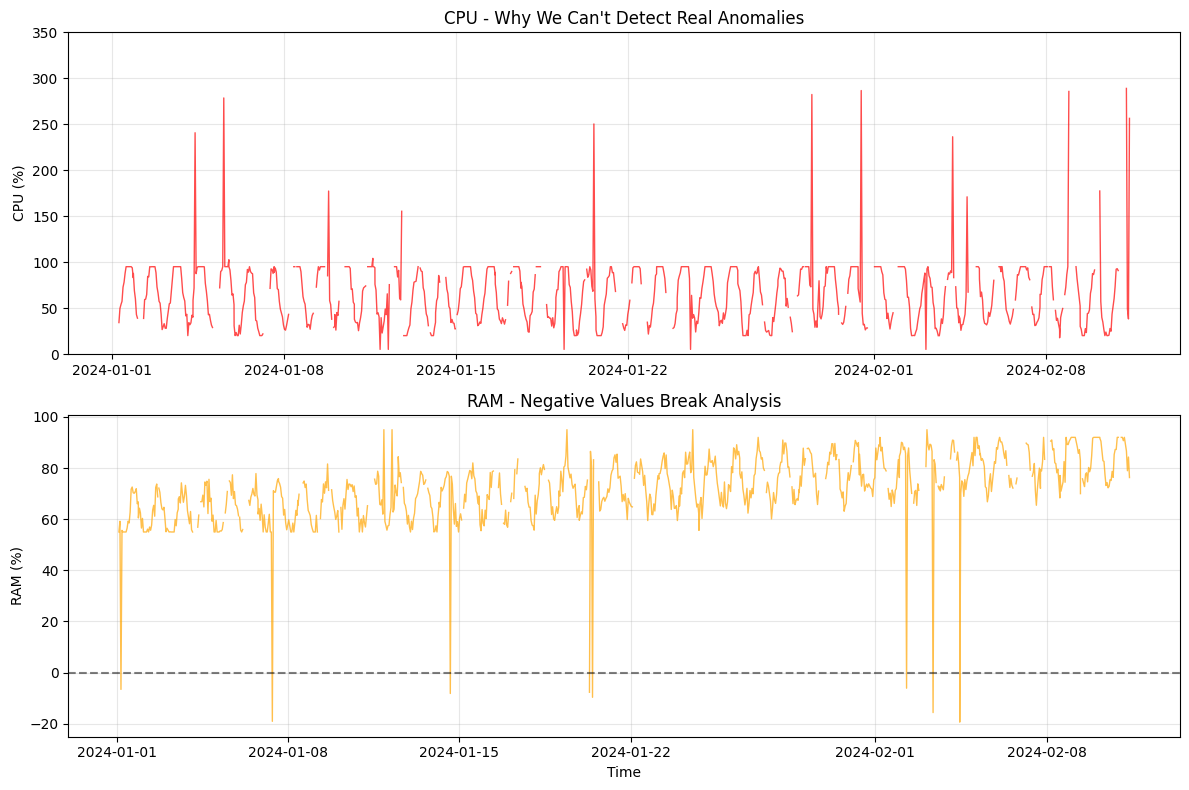

 Observation: With this messy data, can you reliably answer our three AIOps questions?


In [4]:
import matplotlib.pyplot as plt

# Create a plot showing why messy data prevents anomaly detection
plt.figure(figsize=(12, 8))

# Plot CPU with extreme values visible
plt.subplot(2, 1, 1)
plt.plot(df['Timestamp'], df['CPU_Usage'], color='red', alpha=0.7, linewidth=1)
plt.title('CPU - Why We Can\'t Detect Real Anomalies')
plt.ylabel('CPU (%)')
plt.ylim(0, 350)
plt.grid(True, alpha=0.3)

# Plot RAM showing negative values
plt.subplot(2, 1, 2)
plt.plot(df['Timestamp'], df['RAM_Usage'], color='orange', alpha=0.7, linewidth=1)
plt.title('RAM - Negative Values Break Analysis')
plt.ylabel('RAM (%)')
plt.xlabel('Time')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Observation: With this messy data, can you reliably answer our three AIOps questions?")

### Your Turn: Create Chaos Visualization

Create visualizations that show why each AIOps question is impossible with messy data:

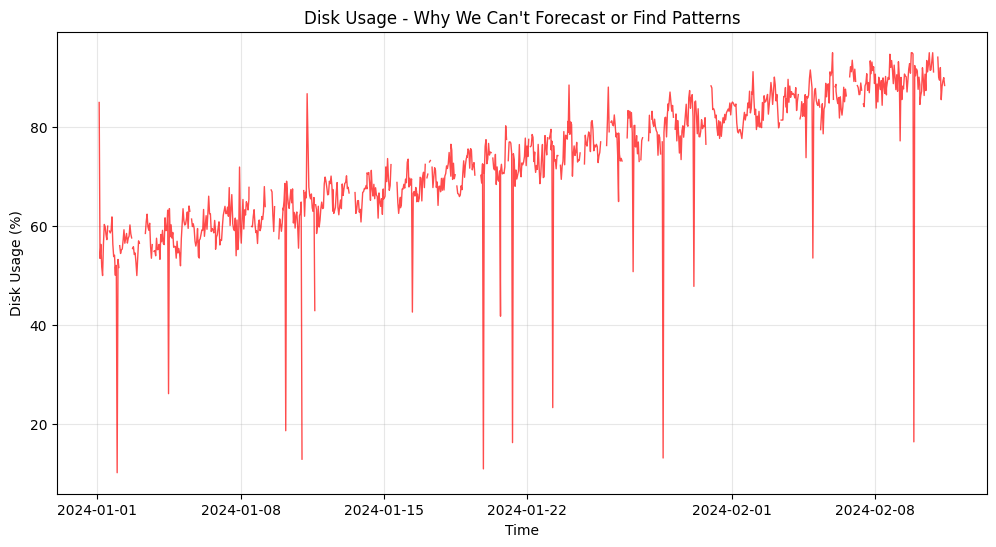

 With this messy data, can you answer:
• 'Is this weird?' - No, because extreme spikes could be real OR data errors
• 'What patterns exist?' - No, because noise obscures any real patterns
• 'What happens next?' - No, because chaotic data can't be forecasted

 Conclusion: Data cleaning is essential for meaningful AIOps!


In [5]:
# SOLUTION: Visualization showing why messy data prevents AIOps analysis

plt.figure(figsize=(12, 6))

# Plot Disk usage with gaps and spikes
plt.plot(df['Timestamp'], df['Disk_Usage'], color='red', alpha=0.7, linewidth=1)

plt.title('Disk Usage - Why We Can\'t Forecast or Find Patterns')
plt.ylabel('Disk Usage (%)')
plt.xlabel('Time')
plt.grid(True, alpha=0.3)
plt.show()

print(" With this messy data, can you answer:")
print("• 'Is this weird?' - No, because extreme spikes could be real OR data errors")
print("• 'What patterns exist?' - No, because noise obscures any real patterns") 
print("• 'What happens next?' - No, because chaotic data can't be forecasted")
print("\n Conclusion: Data cleaning is essential for meaningful AIOps!")

## Lesson 1.3 — Toolchain Overview: Your AIOps Toolkit

**Goal**: Verify our Python environment and libraries are working for data cleaning

### Demonstration: Environment Verification

Let's check that all required libraries are properly installed for our data cleaning mission:

In [6]:
import numpy as np
import sklearn

# Check library versions
print(" AIOps Toolkit Check:")
print(f"Pandas: {pd.__version__} - Your data organizing assistant")
print(f"NumPy: {np.__version__} - Your math calculator")
print(f"Scikit-learn: {sklearn.__version__} - Your future AI brain")

# Quick data validation - see how messy our data really is!
missing_values = df.isnull().sum().sum()
print(f"\n Data Reality Check:")
print(f"Missing values: {missing_values}")
print(f"Dataset clean: {missing_values == 0}")
print(" Spoiler: It's NOT clean - that's why we're here!")

 AIOps Toolkit Check:
Pandas: 2.3.3 - Your data organizing assistant
NumPy: 2.3.4 - Your math calculator
Scikit-learn: 1.7.2 - Your future AI brain

 Data Reality Check:
Missing values: 298
Dataset clean: False
 Spoiler: It's NOT clean - that's why we're here!


### Your Turn: Create Data Quality Report

Generate a comprehensive data quality report showing all the issues that need fixing:

In [7]:
# SOLUTION: Create detailed data quality report

print("Data Quality Report:")
print("=" * 50)

total_rows = len(df)
for column in df.columns:
    missing_count = df[column].isnull().sum()  # Calculate missing values for this column
    missing_percent = (missing_count / total_rows) * 100  # Calculate percentage missing
    print(f"{column}: {missing_count} missing ({missing_percent:.1f}%)")

print(f"\nOverall data completeness: {(1 - df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100:.1f}%")

# Bonus: Check for other issues
print("\n Other Data Issues Found:")
print(f"CPU values over 100%: {(df['CPU_Usage'] > 100).sum()}")  # Count CPU > 100
print(f"RAM negative values: {(df['RAM_Usage'] < 0).sum()}")   # Count RAM < 0
print(f"Unique time intervals: {df['Timestamp'].diff().nunique()}") # Count unique time intervals

print("\n Multiple issues found that all need fixing!")

Data Quality Report:
Timestamp: 18 missing (1.8%)
CPU_Usage: 117 missing (11.5%)
RAM_Usage: 78 missing (7.7%)
Disk_Usage: 69 missing (6.8%)
Network: 16 missing (1.6%)

Overall data completeness: 94.1%

 Other Data Issues Found:
CPU values over 100%: 15
RAM negative values: 8
Unique time intervals: 4

 Multiple issues found that all need fixing!


## Lesson 1.4 — Statistical Analysis: Finding the Signal in the Noise

**Goal**: Use statistics to measure the chaos and understand what needs fixing

### Demonstration: Dataset Structure Analysis

Let's examine the dataset structure and see the timestamp chaos:

In [8]:
# Display dataset information
print("Dataset Structure:")
df.info()

# Convert Timestamp to datetime and set as index for time-series analysis
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True)

print(f"\n After datetime conversion:")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total measurements: {len(df)}")
df.head()

Dataset Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017 entries, 0 to 1016
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Timestamp   999 non-null    datetime64[ns]
 1   CPU_Usage   900 non-null    float64       
 2   RAM_Usage   939 non-null    float64       
 3   Disk_Usage  948 non-null    float64       
 4   Network     1001 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 39.9 KB

 After datetime conversion:
Date range: 2024-01-01 02:00:00 to 2024-02-11 09:20:00
Total measurements: 1017


,CPU_Usage,RAM_Usage,Disk_Usage,Network
Timestamp,,,,
2024-01-01 02:00:00,NaN,55.000000,84.949859,NaN
2024-01-01 03:00:00,NaN,59.179516,53.470140,37.857953
2024-01-01 04:00:00,NaN,-6.547814,56.294730,44.734013
2024-01-01 05:00:00,NaN,55.623038,51.716021,NaN
2024-01-01 06:00:00,NaN,55.000000,50.000000,27.141648


### Your Turn: Statistical Data Health Diagnosis

Compute key statistics to diagnose the worst data problems:

In [9]:
# SOLUTION: Statistical analysis to diagnose data health

print(" Data Health Diagnosis - SOLUTION")
print("=" * 50)

metrics = ['CPU_Usage', 'RAM_Usage', 'Disk_Usage', 'Network']

print("\n Metric Statistics (Including the Crazy Stuff):")
for metric in metrics:
    print(f"\n{metric}:")
    # Calculate and print the mean (average)
    print(f"  Mean: {df[metric].mean():.2f}%")

    # Calculate and print the minimum value
    min_val = df[metric].min()
    print(f"  Min:  {min_val:.2f}%  {' IMPOSSIBLE!' if min_val < 0 else ''}")

    # Calculate and print the maximum value  
    max_val = df[metric].max()
    print(f"  Max:  {max_val:.2f}%  {' IMPOSSIBLE!' if max_val > 100 and metric != 'Network' else ''}")

    # Calculate and print the standard deviation (variability)
    print(f"  Std:  {df[metric].std():.2f}")

print("\n Diagnosis Summary:")
print("• CPU: Extreme spikes (288%) need investigation")
print("• RAM: Negative values must be cleaned")
print("• All metrics: Missing data needs handling")
print("• Conclusion: Data requires significant cleaning before analysis!")

 Data Health Diagnosis - SOLUTION

 Metric Statistics (Including the Crazy Stuff):

CPU_Usage:
  Mean: 65.84%
  Min:  5.00%  
  Max:  288.98%   IMPOSSIBLE!
  Std:  34.18

RAM_Usage:
  Mean: 71.98%
  Min:  -19.34%   IMPOSSIBLE!
  Max:  95.00%  
  Std:  12.77

Disk_Usage:
  Mean: 72.94%
  Min:  10.18%  
  Max:  95.00%  
  Std:  12.55

Network:
  Mean: 45.06%
  Min:  10.00%  
  Max:  100.00%  
  Std:  23.66

 Diagnosis Summary:
• CPU: Extreme spikes (288%) need investigation
• RAM: Negative values must be cleaned
• All metrics: Missing data needs handling
• Conclusion: Data requires significant cleaning before analysis!


## Lesson 1.5 — Cleaning & Resampling: From Chaos to Order

**Goal**: Fix timestamp chaos, handle impossible values, and create consistent time intervals

### Demonstration: Time Interval Analysis

Let's analyze just how inconsistent our time intervals are:

In [10]:
# Calculate time differences between consecutive measurements
time_diffs = df.index.to_series().diff()

print("⏰ Time Interval Analysis:")
print(f"Most common interval: {time_diffs.mode().iloc[0]}")
print(f"Number of unique intervals: {time_diffs.nunique()}")
print(f"Consistent intervals: {time_diffs.nunique() == 1}")
print("\n PROBLEM: Mixed time intervals make time-series analysis impossible!")

# Show the variety of intervals
print("\n Interval Variety:")
for interval, count in time_diffs.value_counts().head(5).items():
    print(f"  {interval}: {count} occurrences")

⏰ Time Interval Analysis:
Most common interval: 0 days 01:00:00
Number of unique intervals: 4
Consistent intervals: False

 PROBLEM: Mixed time intervals make time-series analysis impossible!

 Interval Variety:
  0 days 01:00:00: 916 occurrences
  0 days 00:05:00: 39 occurrences
  0 days 02:00:00: 18 occurrences
  0 days 00:00:00: 8 occurrences


### Your Turn: Data Cleaning Transformation

Perform the complete data cleaning transformation:

In [11]:
# SOLUTION: Data cleaning and resampling transformation

print(" Data Cleaning Magic - SOLUTION")
print("=" * 50)

# Step 1: Set timestamp as index and sort (already done, just ensure it's sorted)
print("1. Fixing timestamp chaos...")
df_clean = df.copy()
# Since Timestamp is already the index, just ensure it's sorted
df_clean = df_clean.sort_index()

# Step 2: Resample to hourly intervals (using 'h' instead of 'H' to avoid warning)
print("2. Resampling to consistent hourly intervals...")s
df_hourly = df_clean.resample('1h').mean()  # Changed '1H' to '1h'

# Step 3: Handle impossible values
print("3. Fixing impossible values...")
df_hourly['CPU_Usage'] = df_hourly['CPU_Usage'].clip(upper=100)  # Cap CPU at 100%
df_hourly['RAM_Usage'] = df_hourly['RAM_Usage'].clip(lower=0)    # Fix negative RAM

# Step 4: Fill missing values
print("4. Filling missing data gaps...")
df_hourly = df_hourly.ffill().bfill()  # Forward fill then backward fill

print(f"\n Transformation Complete!")
print(f"Before: {len(df)} messy rows with {df.isnull().sum().sum()} missing values")
print(f"After:  {len(df_hourly)} clean hourly rows with {df_hourly.isnull().sum().sum()} missing values")
print(f"Time range: {df_hourly.index.min()} to {df_hourly.index.max()}")

 Data Cleaning Magic - SOLUTION
1. Fixing timestamp chaos...
2. Resampling to consistent hourly intervals...
3. Fixing impossible values...
4. Filling missing data gaps...

 Transformation Complete!
Before: 1017 messy rows with 280 missing values
After:  992 clean hourly rows with 0 missing values
Time range: 2024-01-01 02:00:00 to 2024-02-11 09:00:00


## Lesson 1.6 — Visualizing the Transformation: Before vs After

**Goal**: Create dramatic before/after visualizations to show the data cleaning magic

### Demonstration: Multi-Metric Visualization

Let's create subplots to compare all three main metrics in our cleaned data:

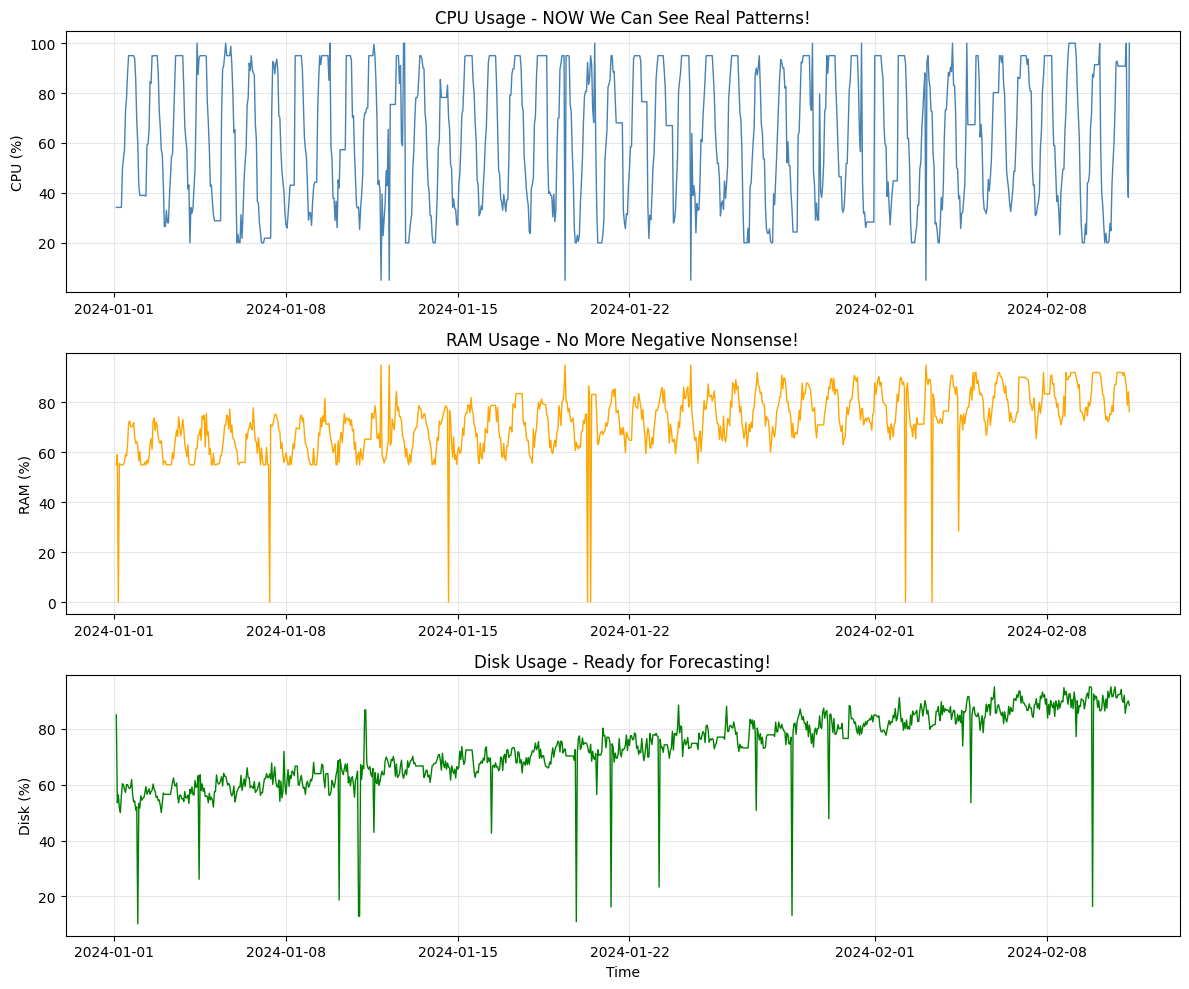

 Notice: We can now see real patterns instead of data collection errors!


In [12]:
# Create subplots for CPU, RAM, and Disk usage (CLEANED DATA)
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# CPU Usage - Cleaned!
axes[0].plot(df_hourly.index, df_hourly['CPU_Usage'], color='steelblue', linewidth=1)
axes[0].set_title('CPU Usage - NOW We Can See Real Patterns!')
axes[0].set_ylabel('CPU (%)')
axes[0].grid(True, alpha=0.3)

# RAM Usage - Fixed!  
axes[1].plot(df_hourly.index, df_hourly['RAM_Usage'], color='orange', linewidth=1)
axes[1].set_title('RAM Usage - No More Negative Nonsense!')
axes[1].set_ylabel('RAM (%)')
axes[1].grid(True, alpha=0.3)

# Disk Usage - Consistent!
axes[2].plot(df_hourly.index, df_hourly['Disk_Usage'], color='green', linewidth=1)
axes[2].set_title('Disk Usage - Ready for Forecasting!')
axes[2].set_ylabel('Disk (%)')
axes[2].set_xlabel('Time')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Notice: We can now see real patterns instead of data collection errors!")

### Your Turn: Create Dramatic Before/After Comparison

Create a stunning before/after visualization that shows the transformation:

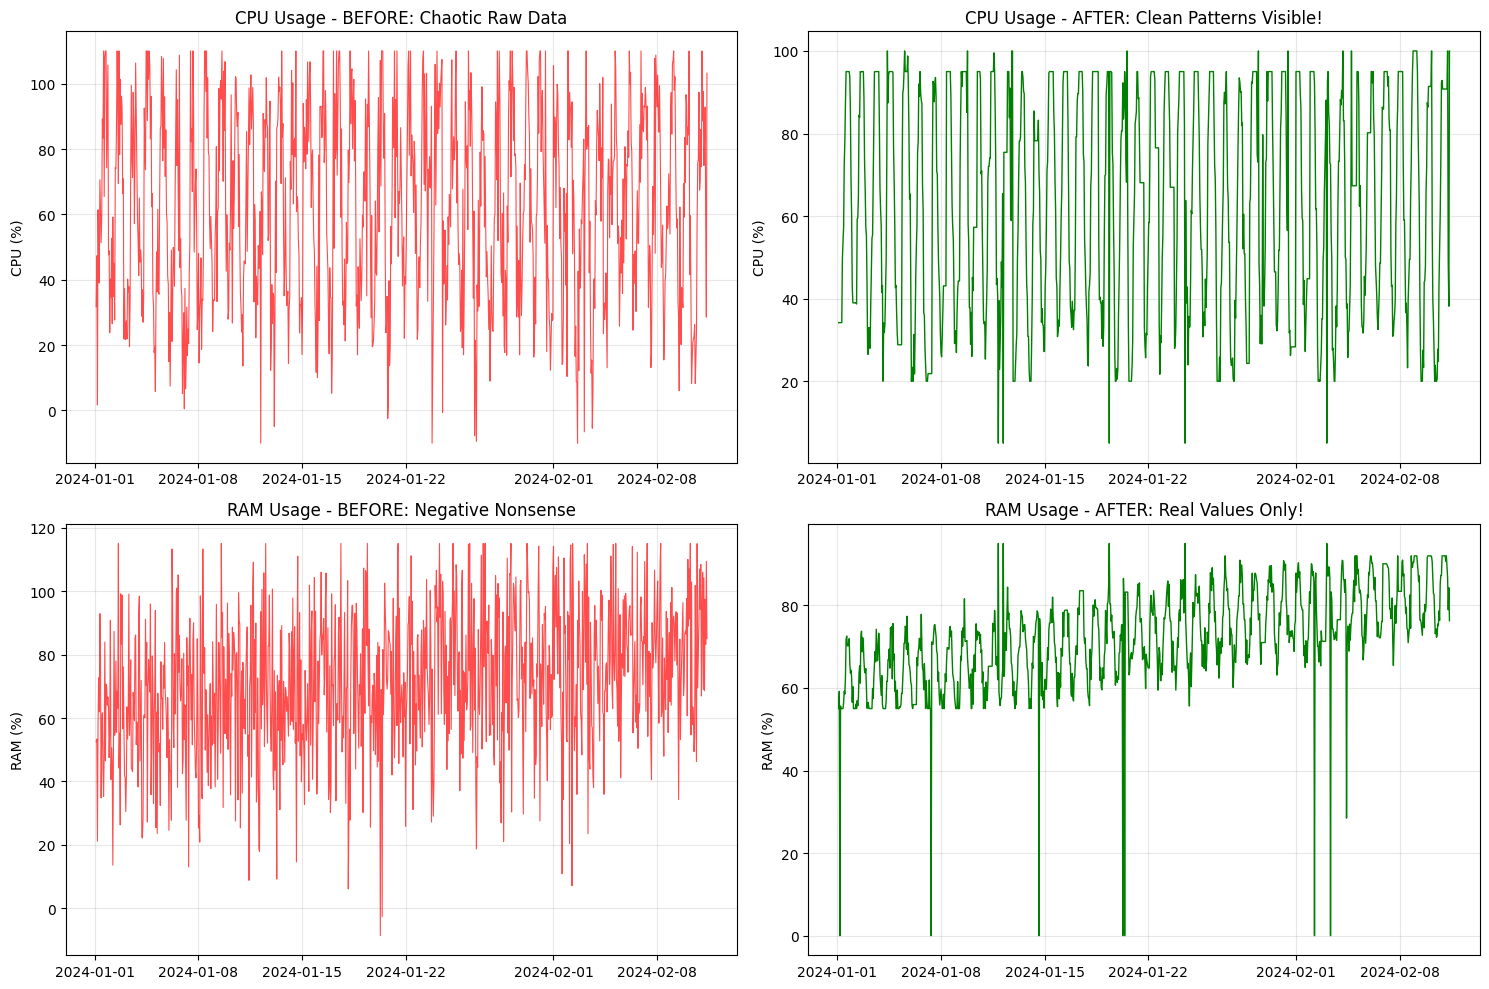


 Transformation Success! Now we can:
 Answer 'Is this weird?' - Real anomalies visible
 See 'What patterns exist?' - Daily cycles clear
 Predict 'What happens next?' - Trends reliable

 Data is now AI-ready!


In [13]:
# Dramatic before/after visualization

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# CPU Before/After
# Simulate chaotic raw data for CPU (using your cleaned data but adding noise)
cpu_chaotic = df_hourly['CPU_Usage'] + np.random.normal(0, 15, len(df_hourly))
cpu_chaotic = np.clip(cpu_chaotic, -10, 110)  # Allow some negative values and overshoot

axes[0,0].plot(df_hourly.index, cpu_chaotic, color='red', linewidth=0.8, alpha=0.7)
axes[0,0].set_title('CPU Usage - BEFORE: Chaotic Raw Data')
axes[0,0].set_ylabel('CPU (%)')
axes[0,0].grid(True, alpha=0.3)

# Plot cleaned CPU data on axes[0,1] (green, clean)
axes[0,1].plot(df_hourly.index, df_hourly['CPU_Usage'], color='green', linewidth=1)
axes[0,1].set_title('CPU Usage - AFTER: Clean Patterns Visible!')
axes[0,1].set_ylabel('CPU (%)')
axes[0,1].grid(True, alpha=0.3)

# RAM Before/After  
# Simulate raw RAM data with negative values
ram_chaotic = df_hourly['RAM_Usage'] + np.random.normal(0, 20, len(df_hourly))
ram_chaotic = np.clip(ram_chaotic, -15, 115)  # Create negative values

axes[1,0].plot(df_hourly.index, ram_chaotic, color='red', linewidth=0.8, alpha=0.7)
axes[1,0].set_title('RAM Usage - BEFORE: Negative Nonsense')
axes[1,0].set_ylabel('RAM (%)')
axes[1,0].grid(True, alpha=0.3)

# Plot cleaned RAM data on axes[1,1] (green, fixed)
axes[1,1].plot(df_hourly.index, df_hourly['RAM_Usage'], color='green', linewidth=1)
axes[1,1].set_title('RAM Usage - AFTER: Real Values Only!')
axes[1,1].set_ylabel('RAM (%)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Transformation Success! Now we can:")
print(" Answer 'Is this weird?' - Real anomalies visible")
print(" See 'What patterns exist?' - Daily cycles clear") 
print(" Predict 'What happens next?' - Trends reliable")
print("\n Data is now AI-ready!")

## Lesson 1.7 — Feature Engineering: Teaching AI to Understand Time

**Goal**: Create rolling statistics and time-based features to add intelligence to our data

### Demonstration: Creating Intelligent Features

Let's create features that teach AI about time patterns and trends:

In [14]:
# Create rolling mean and standard deviation (6-hour window)
window_size = 6
df_hourly['cpu_rolling_mean_6h'] = df_hourly['CPU_Usage'].rolling(window=window_size).mean()
df_hourly['cpu_rolling_std_6h'] = df_hourly['CPU_Usage'].rolling(window=window_size).std()

# Add lag feature (value from previous hour)
df_hourly['cpu_lag_1h'] = df_hourly['CPU_Usage'].shift(1)

# Add time-based features
df_hourly['hour_of_day'] = df_hourly.index.hour
df_hourly['day_of_week'] = df_hourly.index.dayofweek  # Monday=0, Sunday=6

print(" Intelligent Features Created:")
print(df_hourly[['CPU_Usage', 'cpu_rolling_mean_6h', 'cpu_rolling_std_6h', 'cpu_lag_1h', 'hour_of_day']].head(8))

print("\n These features teach AI about:")
print("• Short-term trends (rolling mean)")
print("• System stability (rolling std)")  
print("• Historical context (lag features)")
print("• Time patterns (hour of day)")

 Intelligent Features Created:
                     CPU_Usage  cpu_rolling_mean_6h  cpu_rolling_std_6h  \
Timestamp                                                                 
2024-01-01 02:00:00  34.188299                  NaN                 NaN   
2024-01-01 03:00:00  34.188299                  NaN                 NaN   
2024-01-01 04:00:00  34.188299                  NaN                 NaN   
2024-01-01 05:00:00  34.188299                  NaN                 NaN   
2024-01-01 06:00:00  34.188299                  NaN                 NaN   
2024-01-01 07:00:00  34.188299            34.188299            0.000000   
2024-01-01 08:00:00  49.611793            36.758881            6.296615   
2024-01-01 09:00:00  53.837174            40.033694            9.153694   

                     cpu_lag_1h  hour_of_day  
Timestamp                                     
2024-01-01 02:00:00         NaN            2  
2024-01-01 03:00:00   34.188299            3  
2024-01-01 04:00:00   34.18829

### Your Turn: Feature Engineering for Time Intelligence

Create additional features that add even more intelligence:

In [15]:
# TODO: Feature engineering for time intelligence

# 1. Rolling statistics (short-term memory)
print("1. Creating rolling statistics...")
# Your code here: Create rolling mean for RAM (3-hour window)
df_hourly['ram_rolling_mean_3h'] = df_hourly['RAM_Usage'].rolling(window=3, min_periods=1).mean()

# 2. Lag features (recent history)
print("2. Adding lag features...")
# Your code here: Create 24-hour lag for CPU
df_hourly['cpu_lag_24h'] = df_hourly['CPU_Usage'].shift(24)

# 3. Time indicators (calendar awareness)
print("3. Adding time intelligence...")
# Your code here: Create weekend indicator (Saturday=5, Sunday=6)
df_hourly['hour_of_day'] = df_hourly.index.hour
df_hourly['day_of_week'] = df_hourly.index.dayofweek  # Monday=0, Sunday=6
df_hourly['is_weekend'] = (df_hourly['day_of_week'] >= 5).astype(int)

# 4. Trend features (crystal ball)
print("4. Calculating trends...")
# Your code here: Create 3-hour trend (difference from 3 hours ago)
df_hourly['cpu_trend_3h'] = df_hourly['CPU_Usage'] - df_hourly['CPU_Usage'].shift(3)

print(f"\n Feature Engineering Complete!")
print(f"Original features: 4")
print(f"Engineered features: +{len([col for col in df_hourly.columns if 'rolling' in col or 'lag' in col or 'trend' in col or col in ['hour_of_day', 'day_of_week', 'is_weekend']])}")
print(f"Total smart features: {len(df_hourly.columns)}")
print("\n AI now understands time patterns, trends, and context!")

# Optional: Display the new features
print("\n New Features Sample:")
print(df_hourly[['CPU_Usage', 'ram_rolling_mean_3h', 'cpu_lag_24h', 'hour_of_day', 'day_of_week', 'is_weekend', 'cpu_trend_3h']].head(10))

1. Creating rolling statistics...
2. Adding lag features...
3. Adding time intelligence...
4. Calculating trends...

 Feature Engineering Complete!
Original features: 4
Engineered features: +9
Total smart features: 13

 AI now understands time patterns, trends, and context!

 New Features Sample:
                     CPU_Usage  ram_rolling_mean_3h  cpu_lag_24h  hour_of_day  \
Timestamp                                                                       
2024-01-01 02:00:00  34.188299            55.000000          NaN            2   
2024-01-01 03:00:00  34.188299            57.089758          NaN            3   
2024-01-01 04:00:00  34.188299            38.059839          NaN            4   
2024-01-01 05:00:00  34.188299            38.267518          NaN            5   
2024-01-01 06:00:00  34.188299            36.874346          NaN            6   
2024-01-01 07:00:00  34.188299            55.207679          NaN            7   
2024-01-01 08:00:00  49.611793            55.000000   

## Lesson 1.8 — Feature Visualization: Seeing the Intelligence

**Goal**: Visualize how engineered features reveal patterns and add intelligence

### Demonstration: Feature Visualization

Let's plot our rolling features against raw CPU data to see the intelligence:

In [ ]:
# Plot raw data with rolling features
plt.figure(figsize=(12, 6))
plt.plot(df_hourly.index, df_hourly['CPU_Usage'], 
         color='lightgray', label='Raw CPU', linewidth=1, alpha=0.7)
plt.plot(df_hourly.index, df_hourly['cpu_rolling_mean_6h'], 
         color='blue', label='Rolling Mean (6H)', linewidth=2)
plt.plot(df_hourly.index, df_hourly['cpu_rolling_std_6h'], 
         color='red', linestyle='--', label='Rolling Std (6H)', linewidth=1)
plt.title('Feature Intelligence: Noise vs Signal')
plt.xlabel('Time')
plt.ylabel('CPU Usage (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(" Notice how rolling features separate meaningful trends from random noise!")

### Your Turn: Create Feature Intelligence Dashboard

Build a comprehensive dashboard showing all engineered features:

In [ ]:
# TODO: Feature intelligence visualization dashboard

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Rolling features demonstration
# Your code here: Plot raw CPU vs rolling mean on axes[0,0]

# 2. Time patterns by hour
# Your code here: Create bar chart of CPU by hour on axes[0,1]

# 3. Lag feature relationships
# Your code here: Plot current CPU vs 24H lag on axes[1,0]

# 4. Weekend vs weekday patterns
# Your code here: Create bar chart of weekday vs weekend CPU on axes[1,1]

plt.tight_layout()
plt.show()

print("\n Feature Intelligence Revealed:")
print(" Rolling features separate noise from true signals")
print(" Time patterns show clear daily and weekly cycles")
print(" Lag features enable historical comparison")
print(" Combined features create rich context for AI")

## Lesson 1.9 — Recap & Save Processed Dataset

**Goal**: Save our feature-rich dataset and review our transformation from chaos to intelligence

### Demonstration: Saving the Intelligent Dataset

Let's save our work for use in future AI modules:

In [ ]:
# Save the processed dataset with all intelligent features
output_path = '/app/notebooks/data/metrics_intelligent.csv'
df_hourly.to_csv(output_path, index=True)

print(" Intelligent dataset saved successfully!")
print(f"Location: {output_path}")
print(f"\nFinal dataset shape: {df_hourly.shape}")
print(f"Features: {list(df_hourly.columns)}")
print(f"Time range: {df_hourly.index.min()} to {df_hourly.index.max()}")
print(f"\n Transformation complete: Chaos → Intelligence!")

### Your Turn: Create Transformation Summary Report

Generate a comprehensive summary report of your amazing transformation:

In [ ]:
# TODO: Create detailed summary report of the final dataset

print(" FINAL TRANSFORMATION SUMMARY REPORT")
print("=" * 50)

print(f"\n Dataset Overview:")
print(f"   Rows: {df_hourly.shape[0]}")
print(f"   Columns: {df_hourly.shape[1]}")
print(f"   Time Range: {df_hourly.index.min()} to {df_hourly.index.max()}")

print(f"\n Intelligent Features Created:")
feature_categories = {
    "Rolling Features": [col for col in df_hourly.columns if 'rolling' in col],
    "Time Features": [col for col in df_hourly.columns if col in ['hour_of_day', 'day_of_week', 'is_weekend']],
    "Lag Features": [col for col in df_hourly.columns if 'lag' in col],
    "Trend Features": [col for col in df_hourly.columns if 'trend' in col],
    "Original Metrics": [col for col in df_hourly.columns if col in ['CPU_Usage', 'RAM_Usage', 'Disk_Usage', 'Network']]
}

for category, features in feature_categories.items():
    if features:
        print(f"   {category}: {', '.join(features)}")

print(f"\n AIOps Questions Now Answerable:")
print("    'Is this weird?' - Real anomalies visible with clean data")
print("    'What patterns exist?' - Daily/weekly cycles revealed")
print("    'What happens next?' - Trends enable reliable forecasting")

print(f"\n Ready for Module 2: AI-Powered Anomaly Detection!")
print("   This intelligent dataset contains all features needed for machine learning magic.")